In [68]:
%load_ext autoreload
%autoreload 2

In [27]:
# filename = '/mnt/disk1/xueying/JAEGER/models/assays/nov_and_ghddi/jtvae/nov_and_ghddi-vocab.pkl'
filename = '/mnt/disk1/xueying/JAEGER/models/assays/antimalaria/jtvae/antimalaria-vocab.pkl'

In [28]:
import pickle
from mol_tree import Vocab

with open(filename, "rb") as input:
    reopened = pickle.load(input)

In [29]:
len(reopened.vocab)

111

In [30]:
reopened.vocab[:5]

['CCl', 'CF', 'C1COCO1', 'C1=CCNC=C1', 'C1=CCCC=C1']

In [26]:
reopened.vocab[:5]

['[CH:15]1=[CH:16][CH:17]=[CH:18][O:20]1',
 '[CH2:6]1[CH2:7][CH:8]2[CH:9]=[CH:14][CH:15]1[CH:16]=[CH:21]2',
 '[CH:24]1=[CH:25][CH:26]=[CH:38][CH:39]=[CH:40]1',
 '[CH:8]1=[CH:9][CH:10]=[CH:11][CH:13]=[CH:23]1',
 '[CH:18]1=[CH:19][CH:20]=[CH:21][CH:31]=[CH:32]1']

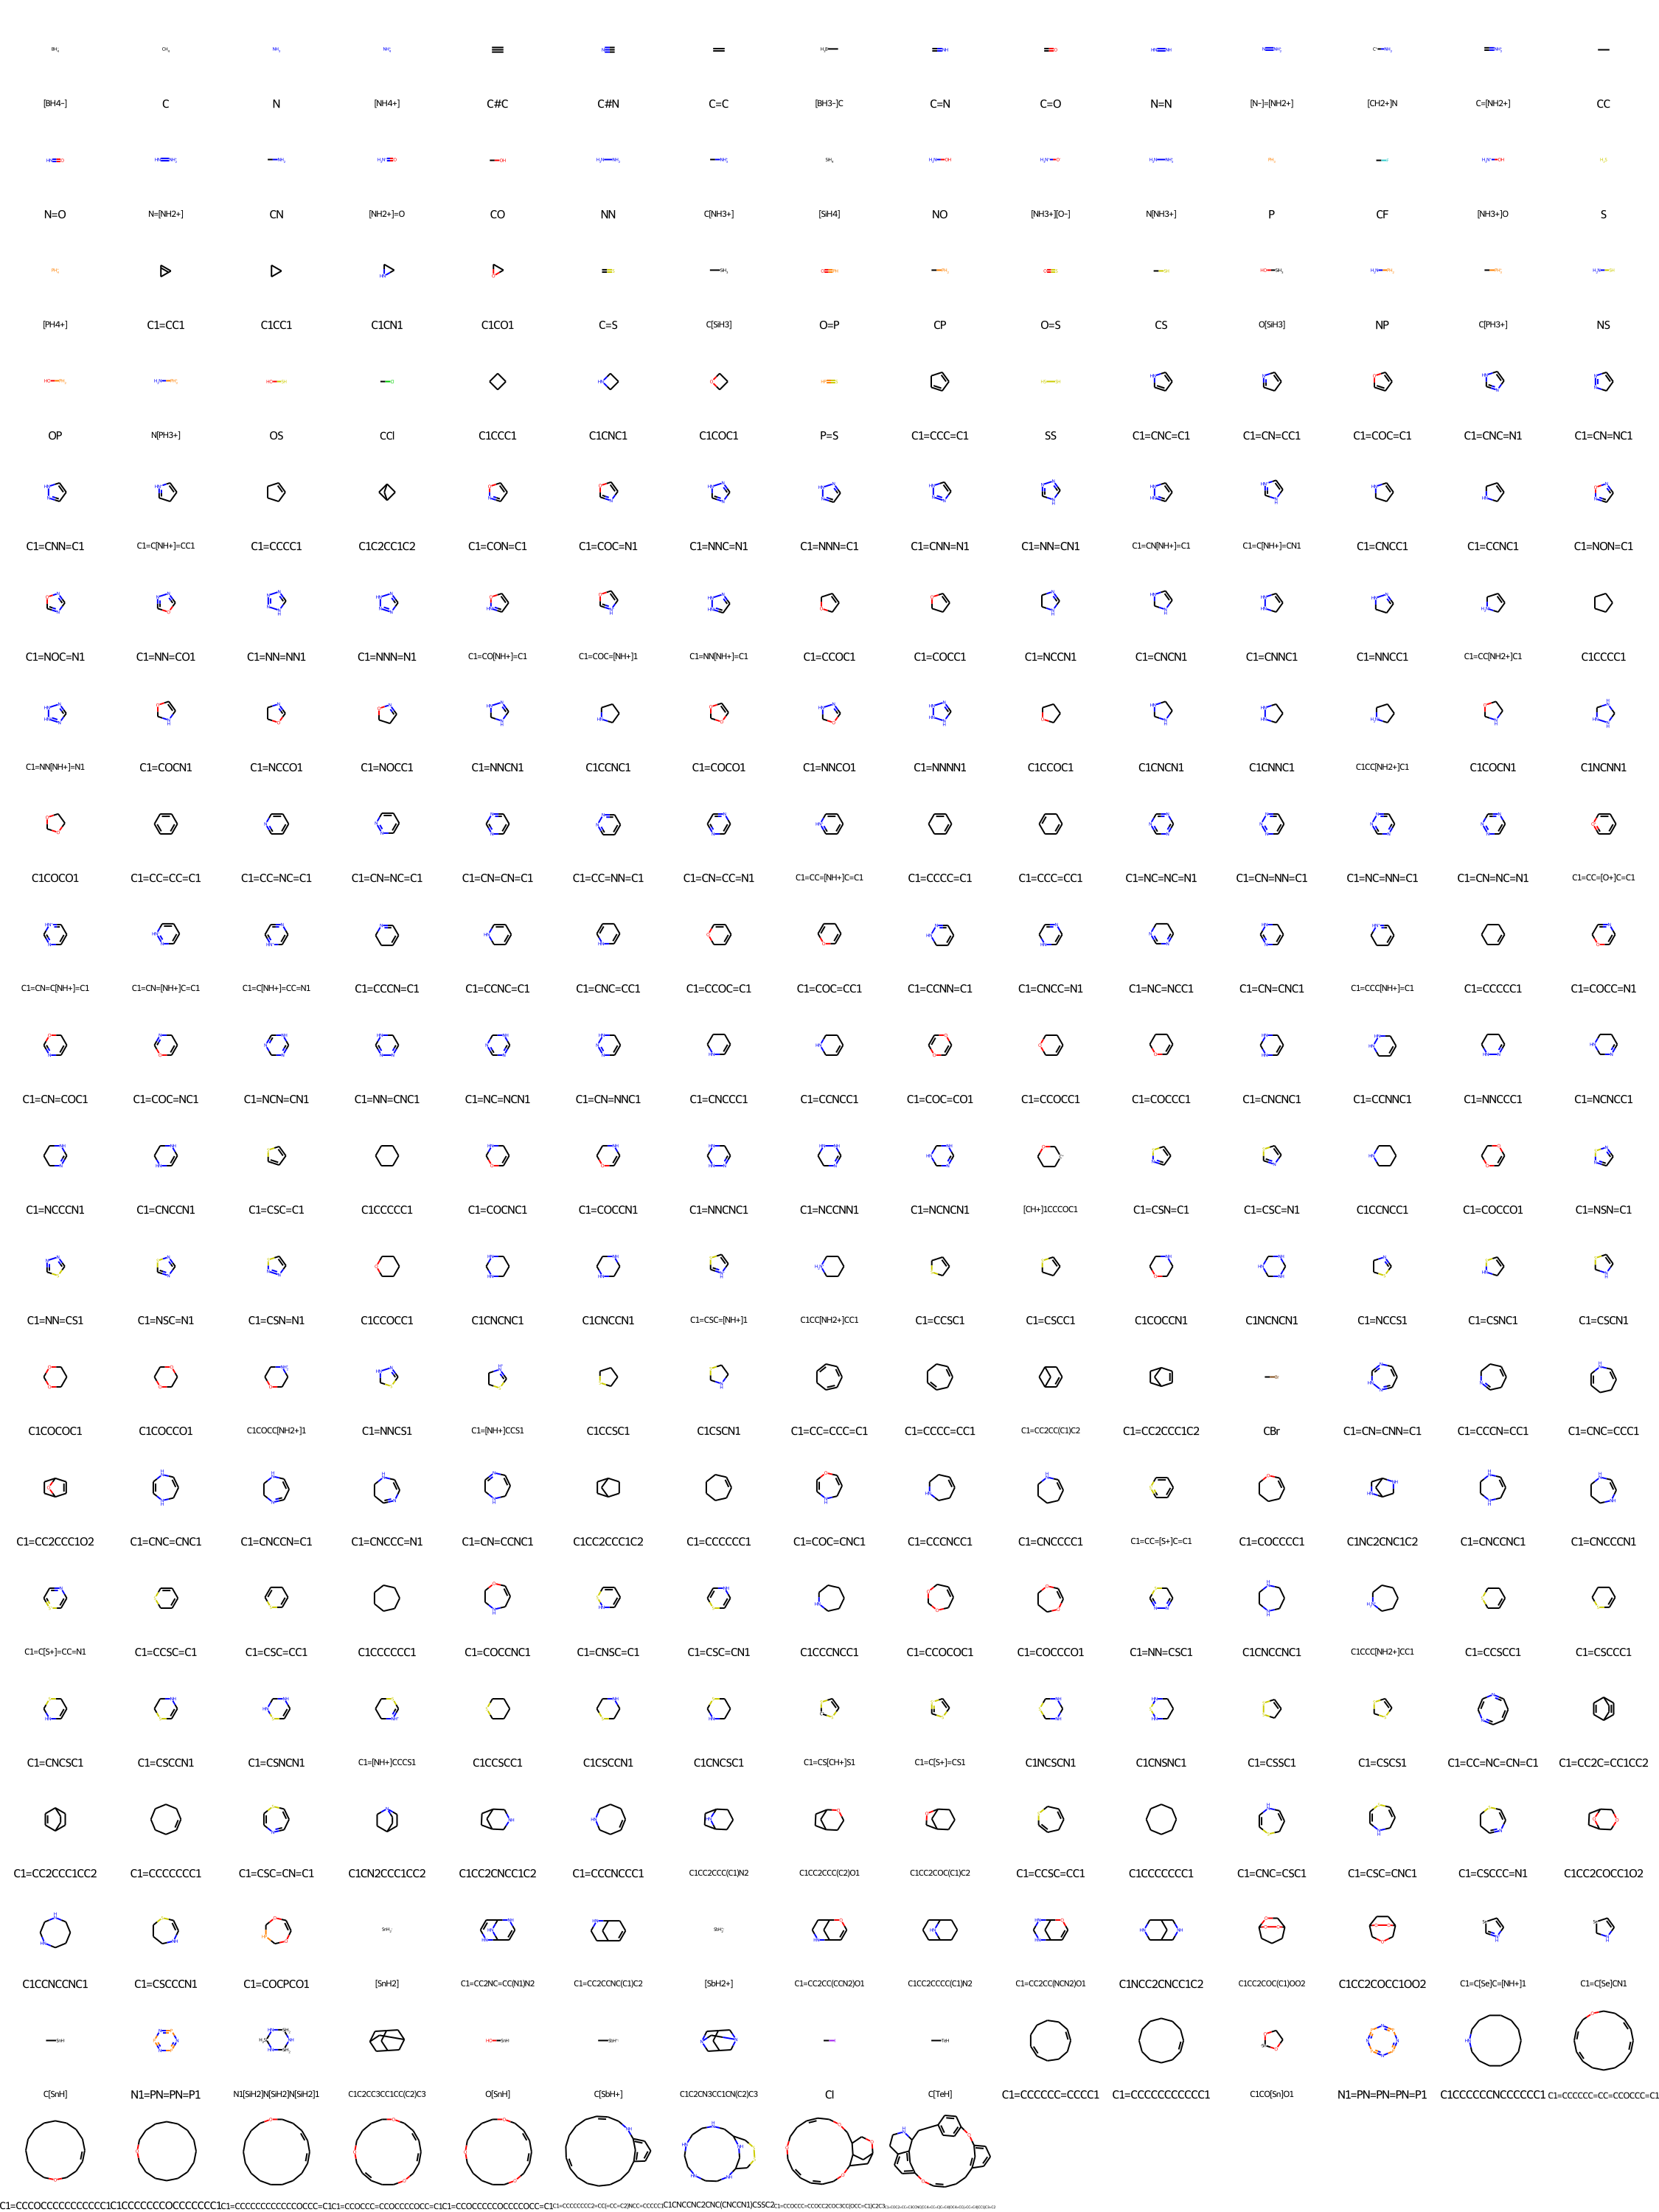

In [21]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors

# 假设 reopened.vocab 是一个包含SMILES字符串的列表
vocab = reopened.vocab  # 确保 reopened.vocab 已经被定义

# 初始化一个列表来存储分子、分子量和SMILES字符串
mol_info = []

# 将SMILES字符串转换为分子对象，并计算分子量
for smi in vocab:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:  # 确保SMILES字符串是有效的
        mol_weight = Descriptors.MolWt(mol)
        mol_info.append((mol, mol_weight, smi))

# 根据分子量对分子信息进行排序
mol_info.sort(key=lambda x: x[1])

# 分离排序后的分子对象、分子量和SMILES字符串
mol_list, weights, smiles_list = zip(*mol_info)

# 绘制分子网格图，将SMILES字符串作为标注
img = Draw.MolsToGridImage(
    mol_list,
    molsPerRow=15,
    subImgSize=(150, 150),
    returnPNG=False,  # 返回图像对象而不是PNG数据
    legends=smiles_list,  # 使用SMILES字符串作为标注
    maxMols=295 #修改展示最大值
)

# 显示图像
img

In [20]:
img.save('/mnt/disk1/xueying/JAEGER/models/assays/nov_and_ghddi/output/vocab.jpg')

In [22]:
len(smiles_list), len(mol_list)

(55, 55)

In [17]:
len(mol_weight_dict)

55

In [10]:
# vocab 画图
from rdkit import Chem
from rdkit.Chem import Draw
mol_list = []
for idx, smi in enumerate(reopened.vocab):
    mol_list.append(Chem.MolFromSmiles(smi))
img = Draw.MolsToGridImage(mol_list, molsPerRow=7, subImgSize=(200, 200), returnPNG=False, legends = reopened.vocab)


/home/xueying/anaconda3/envs/jaeger/lib/python3.9/site-packages/rdkit/Chem/Draw/IPythonConsole.py:252: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


In [11]:
len(mol_list)

55

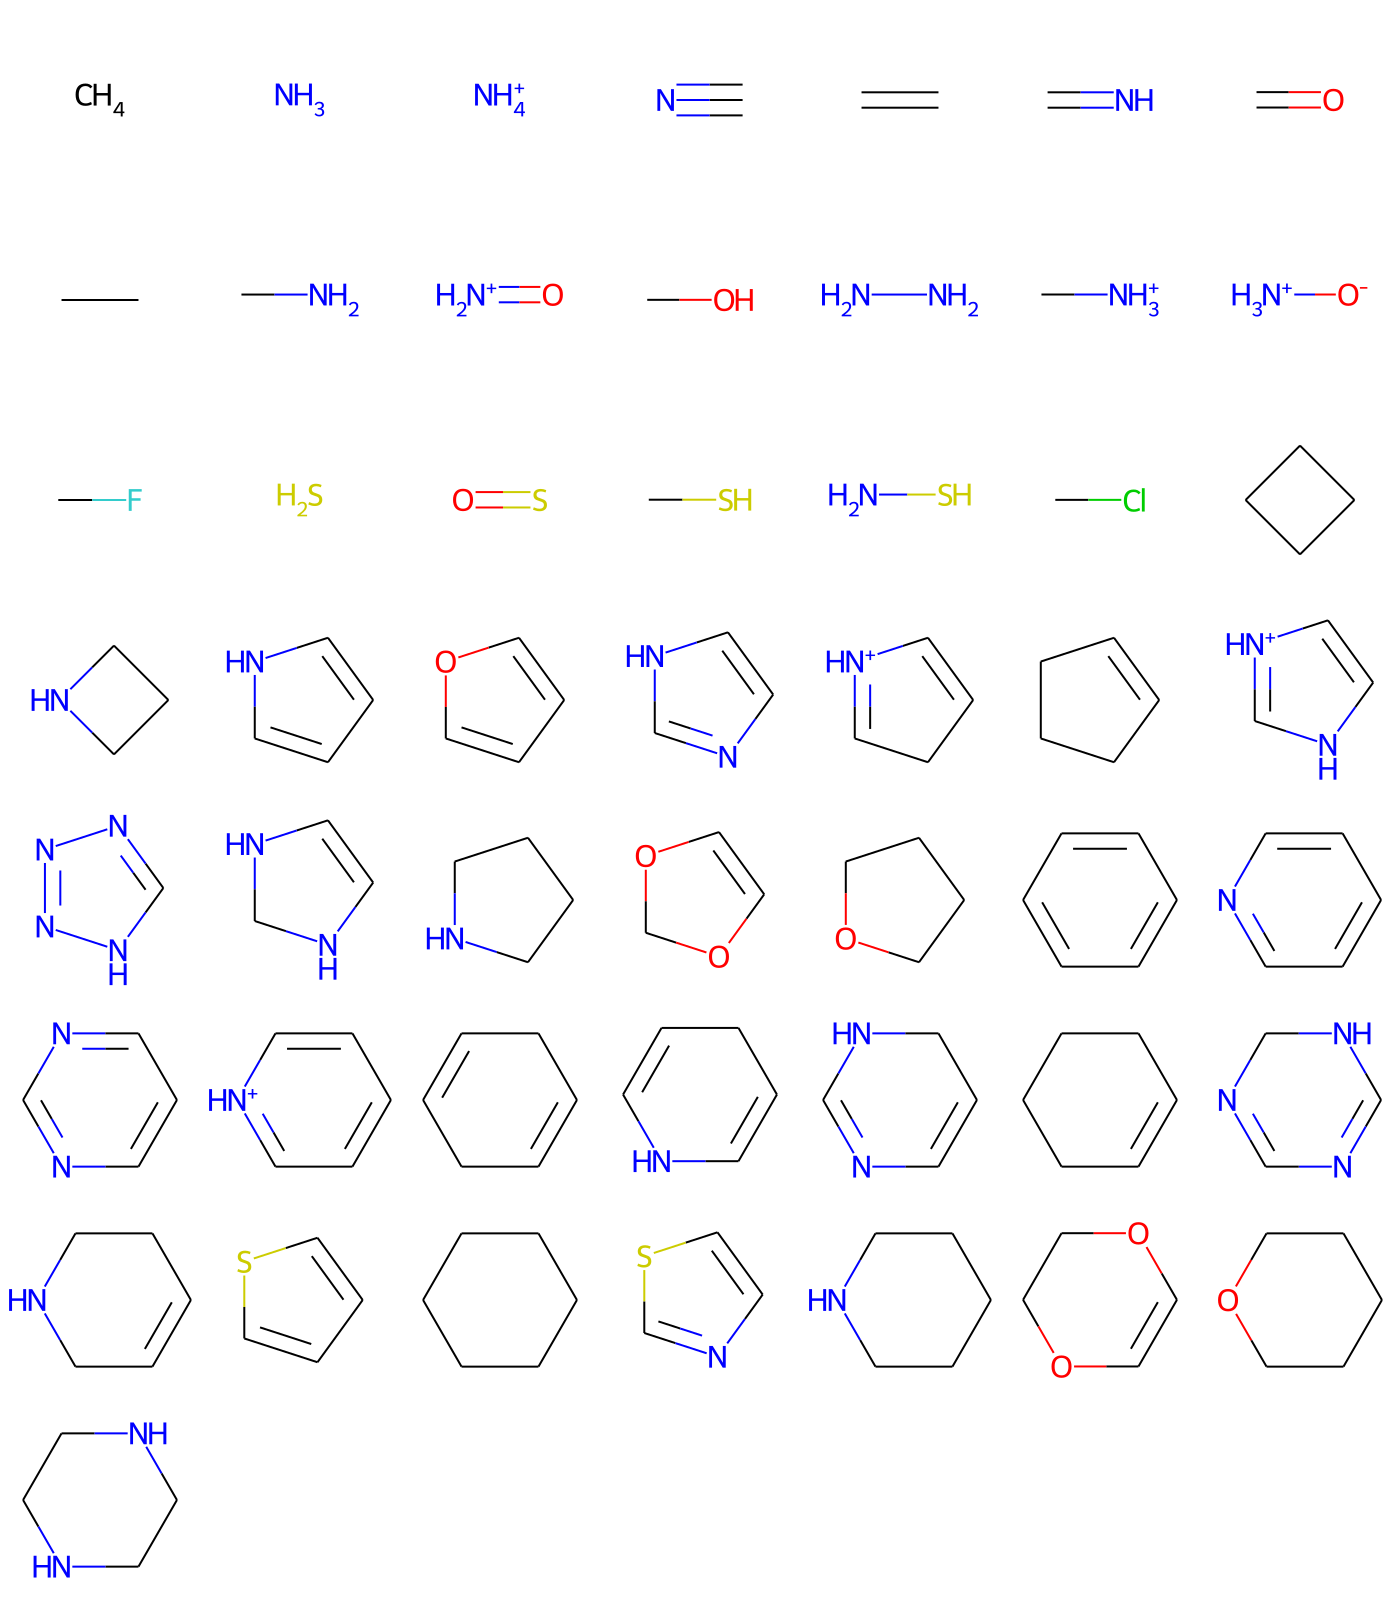

In [18]:
img

In [12]:
reopened.vmap

{'C1=CC=NC=C1': 0,
 'C1=CNC=N1': 1,
 'C1=CNC=C1': 2,
 'C1=CNCN1': 3,
 '[NH2+]=O': 4,
 '[NH4+]': 5,
 'C1CNC1': 6,
 'C1=CCC=CC1': 7,
 'S': 8,
 'C1=NN=NN1': 9,
 'C1CCOCC1': 10,
 'C1=CCNCC1': 11,
 'C1CSCCN1': 12,
 'O=S': 13,
 'NS': 14,
 'C1=COCO1': 15,
 'C=O': 16,
 'C1=CSC=N1': 17,
 'NN': 18,
 'C1=C[NH+]=CC1': 19,
 'C1CCNC1': 20,
 'C1CNCCN1': 21,
 'CS': 22,
 'C1CCCCC1': 23,
 'C1=C[NH+]=CN1': 24,
 'C1CCC1': 25,
 'C1=NC=NCN1': 26,
 'C1=CSC=C1': 27,
 'CO': 28,
 'C1=COCCO1': 29,
 'N': 30,
 'C=N': 31,
 'C1=CC2CCC1O2': 32,
 'C1=CCCC1': 33,
 'CF': 34,
 'CBr': 35,
 'C1=COC2=CC=C3CCNC(CC4=CC=C(C=C4)OC4=CC(=CC=C4)CC1)C3=C2': 36,
 'C1CCNCC1': 37,
 'C1=CC=[NH+]C=C1': 38,
 'C': 39,
 'C1=COC=C1': 40,
 'C=C': 41,
 'CC': 42,
 'C1=CN=CN=C1': 43,
 'C1=CNC=CC1': 44,
 'C1CCCNCC1': 45,
 'CN': 46,
 'C[NH3+]': 47,
 'C1=CC=CC=C1': 48,
 'C#N': 49,
 'CCl': 50,
 'C1=CCCCC1': 51,
 'C1CCOC1': 52,
 'C1=CN=CNC1': 53,
 '[NH3+][O-]': 54}

In [17]:
reopened.slots[-1]

[('N', 1, 3), ('O', -1, 0)]

In [69]:
import rdkit.Chem as Chem

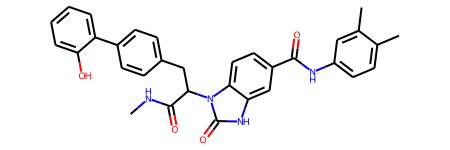

In [24]:
Chem.MolFromSmiles("CNC(=O)C(Cc1ccc(-c2ccccc2O)cc1)n1c(=O)[nH]c2cc(C(=O)Nc3ccc(C)c(C)c3)ccc21")

In [4]:
s = 'CNC(=O)C(Cc1ccc(-c2ccccc2O)cc1)n1c(=O)[nH]c2cc(C(=O)Nc3ccc(C)c(C)c3)ccc21'
from mol_tree import MolTree
mt = MolTree(s)

fast-jtnn
bond
C 0 False 0
N 1 False 0
bond
N 1 False 1
C 2 False 0
bond
C 2 False 2
O 3 False 0
bond
C 2 False 2
C 4 False 0
bond
C 4 False 4
C 5 False 0
bond
C 5 False 5
C 6 True 0
bond
C 6 True 6
C 7 True 0
bond
C 7 True 7
C 8 True 0
bond
C 8 True 8
C 9 True 0
bond
C 9 True 9
C 10 True 0
bond
C 10 True 10
C 11 True 0
bond
C 11 True 11
C 12 True 0
bond
C 12 True 12
C 13 True 0
bond
C 13 True 13
C 14 True 0
bond
C 14 True 14
C 15 True 0
bond
C 15 True 15
O 16 False 0
bond
C 9 True 9
C 17 True 0
bond
C 17 True 17
C 18 True 0
bond
C 4 False 4
N 19 True 0
bond
N 19 True 19
C 20 True 0
bond
C 20 True 20
O 21 False 0
bond
C 20 True 20
N 22 True 0
bond
N 22 True 22
C 23 True 0
bond
C 23 True 23
C 24 True 0
bond
C 24 True 24
C 25 True 0
bond
C 25 True 25
C 26 False 0
bond
C 26 False 26
O 27 False 0
bond
C 26 False 26
N 28 False 0
bond
N 28 False 28
C 29 True 0
bond
C 29 True 29
C 30 True 0
bond
C 30 True 30
C 31 True 0
bond
C 31 True 31
C 32 True 0
bond
C 32 True 32
C 33 False 0
bond
C 32 Tr

In [57]:
# 打印所有属性
for attribute in dir(mt):
    # 检查属性是否应该是一个属性而不是方法或其他内部属性
    if not attribute.startswith('__'):
        # 获取属性的值
        value = getattr(mt, attribute)
        print(f"{attribute}: {value}")

assemble: <bound method MolTree.assemble of <mol_tree.MolTree object at 0x7ff269d178e0>>
mol: <rdkit.Chem.rdchem.Mol object at 0x7ff269c69820>
nodes: [<mol_tree.MolTreeNode object at 0x7ff269d17880>, <mol_tree.MolTreeNode object at 0x7ff269d179d0>, <mol_tree.MolTreeNode object at 0x7ff269d17e80>, <mol_tree.MolTreeNode object at 0x7ff269d17580>, <mol_tree.MolTreeNode object at 0x7ff269d17d30>, <mol_tree.MolTreeNode object at 0x7ff269d174f0>, <mol_tree.MolTreeNode object at 0x7ff269d17730>, <mol_tree.MolTreeNode object at 0x7ff269d17520>, <mol_tree.MolTreeNode object at 0x7ff26bbaf250>, <mol_tree.MolTreeNode object at 0x7ff269d17c40>, <mol_tree.MolTreeNode object at 0x7ff269d173a0>, <mol_tree.MolTreeNode object at 0x7ff269d178b0>, <mol_tree.MolTreeNode object at 0x7ff269d17280>, <mol_tree.MolTreeNode object at 0x7ff269d17e50>, <mol_tree.MolTreeNode object at 0x7ff269d17cd0>, <mol_tree.MolTreeNode object at 0x7ff269d17310>, <mol_tree.MolTreeNode object at 0x7ff269d17700>, <mol_tree.MolTre

In [5]:
from chemutils import tree_decomp
cliques, edges = tree_decomp(mt.mol)

fast-jtnn
bond
C 0 False 0
N 1 False 1
bond
N 1 False 1
C 2 False 2
bond
C 2 False 2
O 3 False 3
bond
C 2 False 2
C 4 False 4
bond
C 4 False 4
C 5 False 5
bond
C 5 False 5
C 6 True 6
bond
C 6 True 6
C 7 True 7
bond
C 7 True 7
C 8 True 8
bond
C 8 True 8
C 9 True 9
bond
C 9 True 9
C 10 True 10
bond
C 10 True 10
C 11 True 11
bond
C 11 True 11
C 12 True 12
bond
C 12 True 12
C 13 True 13
bond
C 13 True 13
C 14 True 14
bond
C 14 True 14
C 15 True 15
bond
C 15 True 15
O 16 False 16
bond
C 9 True 9
C 17 True 17
bond
C 17 True 17
C 18 True 18
bond
C 4 False 4
N 19 True 19
bond
N 19 True 19
C 20 True 20
bond
C 20 True 20
O 21 False 21
bond
C 20 True 20
N 22 True 22
bond
N 22 True 22
C 23 True 23
bond
C 23 True 23
C 24 True 24
bond
C 24 True 24
C 25 True 25
bond
C 25 True 25
C 26 False 26
bond
C 26 False 26
O 27 False 27
bond
C 26 False 26
N 28 False 28
bond
N 28 False 28
C 29 True 29
bond
C 29 True 29
C 30 True 30
bond
C 30 True 30
C 31 True 31
bond
C 31 True 31
C 32 True 32
bond
C 32 True 32
C 

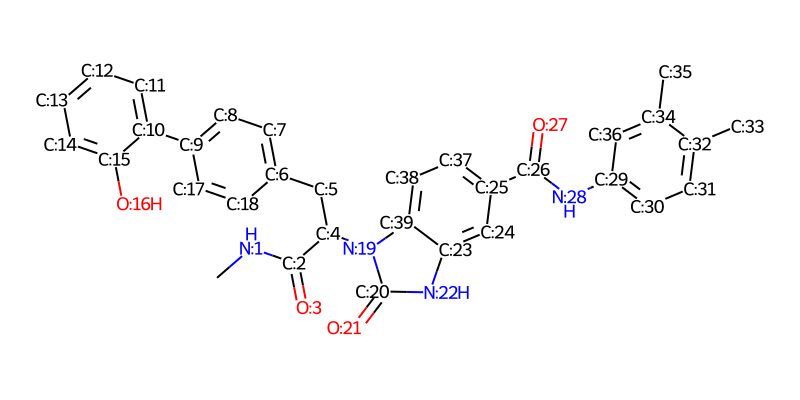

In [85]:
from rdkit.Chem import AllChem, Draw
img_size = (800, 400)
 
# 设置DPI，即清晰度
dpi = 800
 
# 绘制分子图片
img = Draw.MolToImage(mt.mol, size=img_size, dpi=dpi)
img.show()

In [6]:
len(edges)

23

In [7]:
edges

[(0, 1),
 (1, 21),
 (2, 21),
 (3, 21),
 (3, 22),
 (4, 5),
 (4, 22),
 (5, 16),
 (6, 16),
 (6, 17),
 (7, 17),
 (8, 18),
 (8, 22),
 (9, 18),
 (10, 19),
 (10, 23),
 (11, 23),
 (12, 13),
 (12, 23),
 (13, 20),
 (14, 20),
 (15, 20),
 (18, 19)]

In [33]:
cliques

[[0, 1],
 [1, 2],
 [2, 3],
 [2, 4],
 [4, 5],
 [5, 6],
 [9, 10],
 [15, 16],
 [4, 19],
 [20, 21],
 [25, 26],
 [26, 27],
 [26, 28],
 [28, 29],
 [32, 33],
 [34, 35],
 [7, 8, 9, 17, 18, 6],
 [11, 12, 13, 14, 15, 10],
 [20, 19, 39, 23, 22],
 [24, 25, 37, 38, 39, 23],
 [30, 31, 32, 34, 36, 29],
 [2],
 [4],
 [26]]

In [12]:
from collections import defaultdict
edges = defaultdict(int)
edges.update({(0, 1): 1, (1, 21): 1, (2, 21): 1, (3, 21): 1, (3, 22): 1, (4, 22): 1, (8, 22): 1, (4, 5): 1, (5, 16): 1, (6, 16): 1, (6, 17): 1, (7, 17): 1, (8, 18): 1, (9, 18): 1, (18, 19): 2, (10, 19): 1, (10, 23): 1, (11, 23): 1, (12, 23): 1, (12, 13): 1, (13, 20): 1, (14, 20): 1, (15, 20): 1})

In [13]:
MST_MAX_WEIGHT = 100
a = [u + (MST_MAX_WEIGHT-v,) for u,v in edges.items()]

In [14]:
a

[(0, 1, 99),
 (1, 21, 99),
 (2, 21, 99),
 (3, 21, 99),
 (3, 22, 99),
 (4, 22, 99),
 (8, 22, 99),
 (4, 5, 99),
 (5, 16, 99),
 (6, 16, 99),
 (6, 17, 99),
 (7, 17, 99),
 (8, 18, 99),
 (9, 18, 99),
 (18, 19, 98),
 (10, 19, 99),
 (10, 23, 99),
 (11, 23, 99),
 (12, 23, 99),
 (12, 13, 99),
 (13, 20, 99),
 (14, 20, 99),
 (15, 20, 99)]